# Data Exploration
#### The objective of this notebook is to understand the structure and quality of the dataset before descriptor generation and model development.

In [5]:
## Importing Modules
import sys
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import MolsToGridImage 
from rdkit.Chem.Draw import IPythonConsole 
from rdkit.Chem import Descriptors
from rdkit.Chem.rdMolDescriptors import *
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys, AtomPairs, rdFingerprintGenerator
from rdkit.Chem import PandasTools
from rdkit import DataStructs
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray
from rdkit.ML.Descriptors import MoleculeDescriptors
from numpy import prod
from mordred import Calculator, descriptors
from rdkit.Chem import AddHs
from rdkit.Chem.rdmolops import PatternFingerprint
from rdkit.Avalon import pyAvalonTools
from rdkit.Chem.AtomPairs.Pairs import GetAtomPairFingerprintAsBitVect
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import warnings

In [48]:
data = pd.read_csv('delaney.csv')
data

,Compound ID,SMILES,measured log(solubility:mol/L)
0,Acetamide,CC(=O)N,1.580
1,Methanol,CO,1.570
2,Methyl hydrazine,CNN,1.340
3,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144
4,Glycerol,OCC(O)CO,1.120
...,...,...,...
1139,Benzo[ghi]perylene,c1cc2ccc3ccc4ccc5cccc6c(c1)c2c3c4c56,-9.018
1140,"2,2',3,3',5,5',6,6'-PCB",Clc1cc(Cl)c(Cl)c(c1Cl)c2c(Cl)c(Cl)cc(Cl)c2Cl,-9.150
1141,"2,2',3,3',4,4',5,5'-PCB",Clc1cc(c(Cl)c(Cl)c1Cl)c2cc(Cl)c(Cl)c(Cl)c2Cl,-9.160
1142,Coronene,c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67,-9.332


<Figure size 400x600 with 0 Axes>

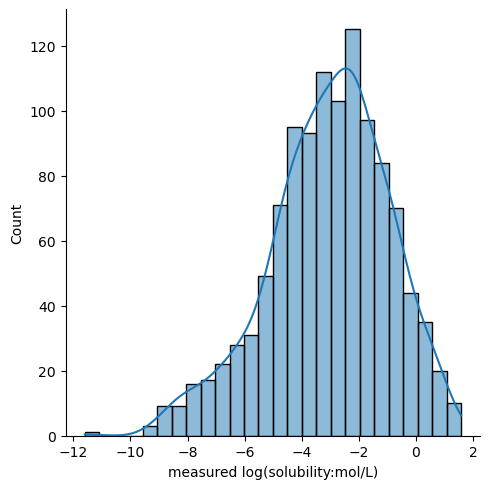

In [25]:
# Exploring how the data is distributed
plt.figure(figsize=(4,6))
plot = sns.displot(data, x='measured log(solubility:mol/L)', kde='True')
plt.savefig('Solubility_distribution.png', dpi=1080, bbox_inches='tight')

### Data distribution
- The distribution of aqueous solubilities is centered around logS value of -3 mol/L with a standard deviation of 2 mol/L.
- Majority (68%) of the compounds lie between the aqueous solubility (logS) range of -5 and -1 mol/L.
- This variability is consistent with experimentally observed solubilties for compounds/scaffolds that fall in "drug-like" chemical space 

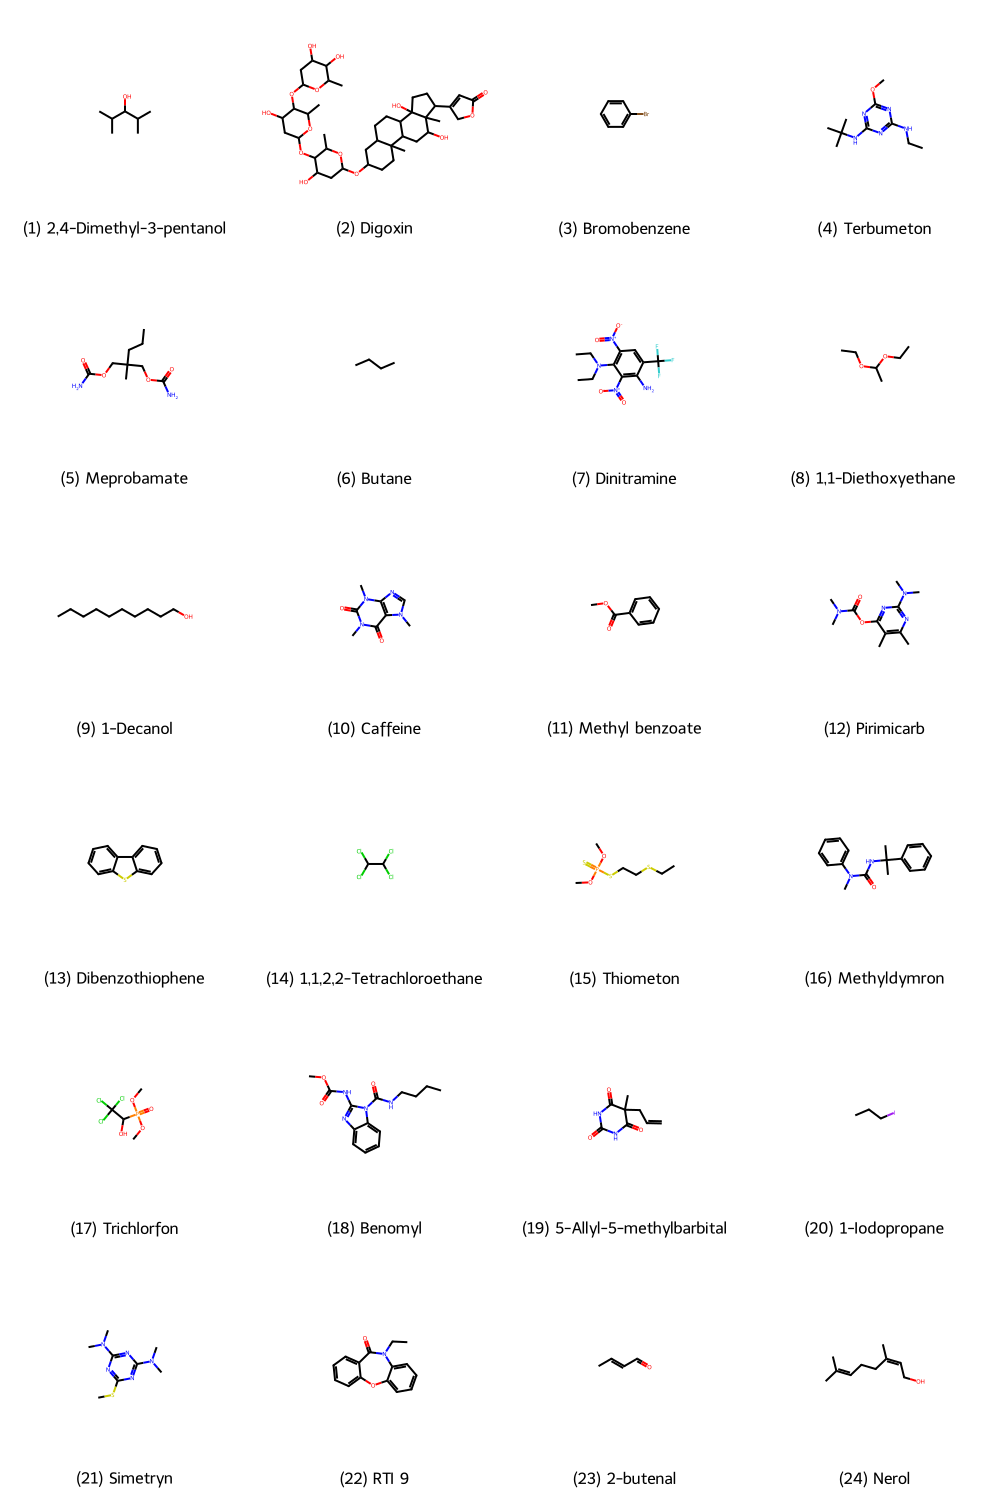

In [51]:
# Viewing the type of molecules in our dataset

sample = data.sample(n=24, random_state=42)

mols = []
labels = []
for i in range(len(sample)):
    smile = sample['SMILES'].iloc[i]
    name = sample['Compound ID'].iloc[i]

    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
        mols.append(mol)
        labels.append(f"({i+1}) {name}")

img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=4, 
    subImgSize=(250, 250),
    legends=labels
)

img

#### Structural information
- The dataset contains 1144 organic molecules
- A representative subset of randomly selected molecules are shown to highlight the structural diversity covered within the chemical space
- These molecules show significant varitation in the identity of the functional groups, different substitution patterns, varying ring systems consistent with the commonly observed drug-like molecular structures